# H3a — Does implied vol overprice jumps that don't persist?

## The specific claim

Realised variance decomposes into a **continuous** part (bipower variation, `bv`) and a
**jump** part (`RV − BV`). These behave differently through time:

- diffusive volatility is highly persistent — it clusters
- jumps are close to memoryless — a 6% gap today says little about tomorrow's vol

If the options market prices *total* recent realised vol, while only the *continuous*
component actually persists, then names that recently jumped carry implied vol that is
systematically too high relative to what will be realised. That is a specific,
mechanistic mispricing rather than "sell vol because IV > RV".

## Three tests, in order

1. **Does BV forecast future RV better than RV?** Pure realised-vol question, no options
   data. If BV does not beat RV, the premise fails and nothing below matters.
2. **Does IV respond to the jump component?** If IV ignores jumps, there is nothing to
   arbitrage.
3. **Does the residual predict the realised IV−RV spread cross-sectionally?** The trade.

Test 1 is cheap and decisive. Run it before caring about the rest.

## Honest priors

The variance risk premium is large, persistent, and mostly *compensation for risk* rather
than mispricing — selling vol earns money for the same reason selling insurance does, and
it fails in the same way. Anything found here has to be shown to be cross-sectional and
not just another way of harvesting the common premium. Every test below is therefore run
on **cross-sectionally demeaned** quantities.

The IV field exported from BQuant sits ~1.47× realised, above the 1.1–1.25 typical of ATM,
so it is probably not at-the-money. A constant multiplicative bias cancels under
cross-sectional ranking, but it means the levels here are not straddle prices.

In [1]:
# ============================ Cell 1 — Load and merge
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

CFG = {
    "rv_panel": "ib_out/rv_panel.parquet",
    "iv_file": "implied_vol.csv",
    "earnings": "earnings_dates.csv",
    "horizon": 21,             # forward RV horizon; ~one option cycle
    "iv_clip": (5, 200),       # vol points; outside this is bad data
    "min_names": 40,
}

rv = pd.read_parquet(CFG["rv_panel"])
rv["session"] = pd.to_datetime(rv["session"]).dt.normalize()

iv = pd.read_csv(CFG["iv_file"], parse_dates=["session"])
iv["ticker"] = iv["ticker"].astype(str).str.split().str[0].str.replace("/", "", regex=False)
iv = iv[(iv["iv"] > CFG["iv_clip"][0]) & (iv["iv"] < CFG["iv_clip"][1])]

d = rv.merge(iv[["ticker", "session", "iv"]], on=["ticker", "session"], how="inner")
print(f"rv panel : {len(rv):,} rows, {rv['ticker'].nunique()} tickers")
print(f"iv file  : {len(iv):,} rows, {iv['ticker'].nunique()} tickers")
print(f"merged   : {len(d):,} rows, {d['ticker'].nunique()} tickers, "
      f"{d['session'].nunique()} sessions")

earn = pd.read_csv(CFG["earnings"], parse_dates=["ann_date"])
earn["ticker"] = earn["ticker"].astype(str).str.split().str[0]
spans = [earn.assign(session=earn["ann_date"] + pd.Timedelta(days=k))[["ticker","session"]]
         for k in range(-5, 3)]      # wider window: IV is elevated well before the print
f = pd.concat(spans, ignore_index=True).drop_duplicates(); f["near_earnings"] = True
d = d.merge(f, on=["ticker","session"], how="left")
d["near_earnings"] = d["near_earnings"].fillna(False).astype(bool)
print(f"near-earnings rows: {d['near_earnings'].mean():.2%}")

H = CFG["horizon"]
d["fwd_rv"] = d[f"fwd_rv{H}"]
d["iv_rv_spread"] = d["iv"] - d["rv5_ma21"]
d["iv_over_rv"] = d["iv"] / d["rv5_ma21"].replace(0, np.nan)
print(f"\nIV / trailing RV: median {d['iv_over_rv'].median():.2f}  "
      f"(ATM would typically be 1.1-1.25)")
print(f"IV - trailing RV: median {d['iv_rv_spread'].median():.2f} vol points")

rv panel : 74,602 rows, 149 tickers
iv file  : 257,235 rows, 502 tickers
merged   : 74,583 rows, 149 tickers, 504 sessions
near-earnings rows: 7.76%

IV / trailing RV: median 1.32  (ATM would typically be 1.1-1.25)
IV - trailing RV: median 6.70 vol points


In [2]:
# ============================ Cell 2 — TEST 1: does BV beat RV at forecasting RV?
# The premise. If the continuous component is not the more persistent part,
# there is no jump mispricing to look for.
print("=" * 72)
print("TEST 1 — forecasting forward realised vol (cross-sectionally demeaned)")
print("=" * 72)

w = d.dropna(subset=["fwd_rv", "rv5_ma21", "bv_ma21", "jump_ma21"]).copy()
for c in ["fwd_rv", "rv5_ma21", "bv_ma21", "jump_ma21", "iv", "vol_of_vol_21"]:
    w[c + "_dm"] = w[c] - w.groupby("session")[c].transform("mean")

def ols(cols, label):
    X = sm.add_constant(w[[c + "_dm" for c in cols]])
    m = sm.OLS(w["fwd_rv_dm"], X).fit(cov_type="HAC", cov_kwds={"maxlags": CFG["horizon"]})
    print(f"\n{label}")
    print(f"   R2 = {m.rsquared:.4f}   n = {int(m.nobs):,}")
    for nm, b, t in zip(m.params.index, m.params.values, m.tvalues.values):
        print(f"   {nm:<22} {b:+8.4f}   t = {t:+7.2f}")
    return m

m_rv = ols(["rv5_ma21"], "(a) total realised vol only")
m_bv = ols(["bv_ma21"], "(b) continuous component only")
m_both = ols(["bv_ma21", "jump_ma21"], "(c) continuous + jump share")

print("\n" + "-" * 72)
print(f"R2: total RV {m_rv.rsquared:.4f} | continuous {m_bv.rsquared:.4f} | "
      f"both {m_both.rsquared:.4f}")
if m_bv.rsquared > m_rv.rsquared:
    print("PREMISE HOLDS: the continuous component forecasts better than total RV.")
else:
    print("PREMISE FAILS: total RV forecasts at least as well as the continuous part.")
    print("   The jump/diffusion split adds nothing here; H3a is dead at test 1.")
jt = m_both.tvalues.get("jump_ma21_dm", np.nan)
print(f"jump coefficient t-stat in (c): {jt:+.2f}  "
      f"(negative = jumps predict LOWER future vol, the effect being claimed)")

TEST 1 — forecasting forward realised vol (cross-sectionally demeaned)

(a) total realised vol only
   R2 = 0.7360   n = 70,330
   const                   -0.0000   t =   -0.00
   rv5_ma21_dm             +0.8736   t =  +69.12

(b) continuous component only
   R2 = 0.7350   n = 70,330
   const                   -0.0000   t =   -0.00
   bv_ma21_dm              +0.9168   t =  +68.00

(c) continuous + jump share
   R2 = 0.7379   n = 70,330
   const                   -0.0000   t =   -0.00
   bv_ma21_dm              +0.9219   t =  +68.70
   jump_ma21_dm            +8.2296   t =   +8.03

------------------------------------------------------------------------
R2: total RV 0.7360 | continuous 0.7350 | both 0.7379
PREMISE FAILS: total RV forecasts at least as well as the continuous part.
   The jump/diffusion split adds nothing here; H3a is dead at test 1.
jump coefficient t-stat in (c): +8.03  (negative = jumps predict LOWER future vol, the effect being claimed)


In [3]:
# ============================ Cell 3 — TEST 2: does IV respond to jumps?
print("=" * 72)
print("TEST 2 — what does implied vol price?")
print("=" * 72)

w2 = d.dropna(subset=["iv", "bv_ma21", "jump_ma21"]).copy()
for c in ["iv", "bv_ma21", "jump_ma21", "rv5_ma21"]:
    w2[c + "_dm"] = w2[c] - w2.groupby("session")[c].transform("mean")

X = sm.add_constant(w2[["bv_ma21_dm", "jump_ma21_dm"]])
m = sm.OLS(w2["iv_dm"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 21})
print(f"\nIV regressed on its components   R2 = {m.rsquared:.4f}  n = {int(m.nobs):,}")
for nm, b, t in zip(m.params.index, m.params.values, m.tvalues.values):
    print(f"   {nm:<22} {b:+8.4f}   t = {t:+7.2f}")

jt = m.tvalues.get("jump_ma21_dm", np.nan)
print(f"\nIV loading on the jump share: t = {jt:+.2f}")
if jt > 2:
    print("   IV DOES respond to jumps. Combined with test 1 showing jumps do not")
    print("   persist, that is the mispricing this hypothesis predicts.")
elif jt < -2:
    print("   IV responds NEGATIVELY to jumps -- opposite to the hypothesis.")
else:
    print("   IV largely ignores the jump component. Nothing to arbitrage:")
    print("   the market is already pricing the persistent part only.")

TEST 2 — what does implied vol price?

IV regressed on its components   R2 = 0.8151  n = 73,242
   const                   +0.0000   t =   +0.00
   bv_ma21_dm              +1.2934   t =  +88.82
   jump_ma21_dm            +2.0863   t =   +1.70

IV loading on the jump share: t = +1.70
   IV largely ignores the jump component. Nothing to arbitrage:
   the market is already pricing the persistent part only.


In [4]:
# ============================ Cell 4 — TEST 3: the tradeable spread
# Rank names by how rich IV is versus a BV-based forecast of future RV, and see
# whether that ranking predicts the realised IV - RV outcome.
print("=" * 72)
print("TEST 3 — does the residual predict the realised variance premium?")
print("=" * 72)

t = d.dropna(subset=["fwd_rv", "iv", "bv_ma21", "jump_ma21", "rv5_ma21"]).copy()
t["premium_realised"] = t["iv"] - t["fwd_rv"]      # what a vol seller actually earns
t["signal"] = t["iv"] - (m_bv.params.get("const", 0)
                         + m_bv.params["bv_ma21_dm"] * t["bv_ma21"])

for c in ["signal", "premium_realised", "iv_rv_spread"]:
    t[c + "_dm"] = t[c] - t.groupby("session")[c].transform("mean")

rows = []
for day, g in t.groupby("session"):
    if len(g) < CFG["min_names"]:
        continue
    n = max(2, len(g) // 5)          # quintiles: options books are not 150 names wide
    rows.append({
        "session": day,
        "ic": g["signal_dm"].corr(g["premium_realised_dm"], method="spearman"),
        "rich_minus_cheap": (g.nlargest(n, "signal_dm")["premium_realised_dm"].mean()
                             - g.nsmallest(n, "signal_dm")["premium_realised_dm"].mean()),
    })
dd = pd.DataFrame(rows).dropna()
n = len(dd)
adj = np.sqrt(CFG["horizon"])        # overlapping 21-day outcomes
print(f"\nsessions            : {n}")
print(f"mean rank IC        : {dd['ic'].mean():+.4f}")
print(f"IC t (overlap-adj)  : {dd['ic'].mean()/dd['ic'].std()*np.sqrt(n)/adj:+.2f}")
print(f"rich-minus-cheap    : {dd['rich_minus_cheap'].mean():+.2f} vol points")
print(f"   t (overlap-adj)  : "
      f"{dd['rich_minus_cheap'].mean()/dd['rich_minus_cheap'].std()*np.sqrt(n)/adj:+.2f}")

print("\nSame test EXCLUDING near-earnings windows:")
te = t[~t["near_earnings"]]
rows = []
for day, g in te.groupby("session"):
    if len(g) < CFG["min_names"]:
        continue
    nq = max(2, len(g) // 5)
    rows.append({"session": day,
                 "ic": g["signal_dm"].corr(g["premium_realised_dm"], method="spearman")})
de = pd.DataFrame(rows).dropna()
print(f"   n = {len(de)}, mean IC {de['ic'].mean():+.4f}, "
      f"t (adj) {de['ic'].mean()/de['ic'].std()*np.sqrt(len(de))/adj:+.2f}")

print("\nCAUTION: vol points are not P&L. Converting this to a tradeable number needs")
print("option prices, vega, bid-ask, and delta-hedging costs. A 1-vol-point edge on a")
print("straddle with a 2-vol-point spread is negative. Treat this as a screen for")
print("whether the effect exists at all, not as a backtest.")

TEST 3 — does the residual predict the realised variance premium?

sessions            : 475
mean rank IC        : +0.6861
IC t (overlap-adj)  : +19.98
rich-minus-cheap    : +7.67 vol points
   t (overlap-adj)  : +16.13

Same test EXCLUDING near-earnings windows:
   n = 475, mean IC +0.6884, t (adj) +20.49

CAUTION: vol points are not P&L. Converting this to a tradeable number needs
option prices, vega, bid-ask, and delta-hedging costs. A 1-vol-point edge on a
straddle with a 2-vol-point spread is negative. Treat this as a screen for
whether the effect exists at all, not as a backtest.


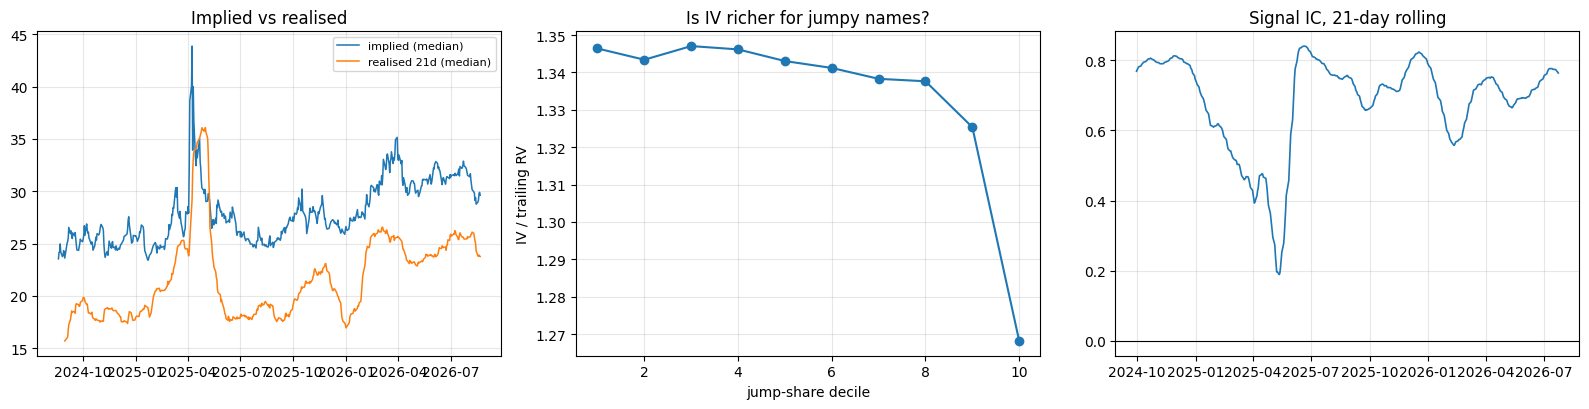

wrote ib_out/iv_rv_panel_20260823.parquet and h3a_daily_20260823.csv


In [5]:
# ============================ Cell 5 — Charts and export
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

s = d.groupby("session")[["iv", "rv5_ma21"]].median()
ax[0].plot(s.index, s["iv"], lw=1.1, label="implied (median)")
ax[0].plot(s.index, s["rv5_ma21"], lw=1.1, label="realised 21d (median)")
ax[0].set_title("Implied vs realised"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

b = d.dropna(subset=["jump_ma21", "iv_over_rv"]).copy()
b["jbin"] = pd.qcut(b["jump_ma21"].rank(method="first"), 10, labels=False) + 1
gb = b.groupby("jbin")[["iv_over_rv", "jump_ma21"]].mean()
ax[1].plot(gb.index, gb["iv_over_rv"], "o-")
ax[1].set_xlabel("jump-share decile"); ax[1].set_ylabel("IV / trailing RV")
ax[1].set_title("Is IV richer for jumpy names?"); ax[1].grid(alpha=.3)

ax[2].plot(dd["session"], dd["ic"].rolling(21).mean(), lw=1.2)
ax[2].axhline(0, color="black", lw=.8)
ax[2].set_title("Signal IC, 21-day rolling"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

stamp = pd.Timestamp.today().strftime("%Y%m%d")
d.to_parquet(f"ib_out/iv_rv_panel_{stamp}.parquet", index=False)
dd.to_csv(f"h3a_daily_{stamp}.csv", index=False)
print(f"wrote ib_out/iv_rv_panel_{stamp}.parquet and h3a_daily_{stamp}.csv")